# Where Will This Vessel Be in 4–6 Hours?
### AIS Vessel Trajectory Forecasting over Extended Horizons
**Author:** Praneeth (ED23B032)  
**Take-Home Assignment:** Blurgs.ai  
**Repository:** [https://github.com/Praneeth4227/Blurgs.ai_Assignment_ED23B032](https://github.com/Praneeth4227/Blurgs.ai_Assignment_ED23B032)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Praneeth4227/Blurgs.ai_Assignment_ED23B032/blob/main/notebooks/Blurgs_Vessel_Trajectory_Forecasting.ipynb)

---

## Notebook Structure & Workflow

This notebook provides the complete, reproducible end-to-end pipeline for forecasting vessel positions at **+4 hours** and **+6 hours** into the future given **approximately 4 hours of historical AIS observations**.

It covers the entire investigation from data understanding and cleaning to modeling, spatial uncertainty analysis, and failure investigation:

1. **Environment Setup** (Colab detection, path resolution, random seeds)
2. **Installation of Required Packages** (`geopy`, `pyyaml`, `pyarrow`, etc.)
3. **Import Statements** (Scientific and geospatial libraries)
4. **Repository & Data Setup** (Automated dataset acquisition)
5. **Data Loading** (NOAA MarineCadastre AIS data)
6. **Data Exploration (EDA)** (Sampling intervals, speeds, courses, missingness)
7. **Data Cleaning** (Coordinate checks, deduplication, physically defensible speed filtering)
8. **Trajectory Construction** (Handling observation gaps and segmenting voyages)
9. **Forecast-Window Generation** (~4h history windows and +4h/+6h targets)
10. **Train / Validation / Test Split** (Strictly chronological, zero lookahead leakage)
11. **Linear Baseline** (+4h, +6h constant velocity extrapolation)
12. **Polynomial Baseline** (+4h, +6h quadratic extrapolation)
13. **Kinematic SOG/COG Model** (+4h, +6h dead-reckoning with circular smoothing)
14. **Kalman Filter Model** (+4h, +6h 4D kinematic state filtering and covariance propagation)
15. **+4h Prediction Generation** (Executing all models on unseen test windows)
16. **+6h Prediction Generation** (Executing all models on unseen test windows)
17. **Quantitative Evaluation** (Geodesic Mean, Median, RMSE, P90 in km + vessel breakdown)
18. **Visualizations** (Error ECDFs, horizon comparison charts, trajectory maps)
19. **Failure Analysis** (Detailed spatial inspection of success vs failure modes)
20. **Uncertainty Discussion** (Kalman covariance ellipses and probabilistic directions)
21. **Final Model Comparison & Colab-to-GitHub Workflow**


---
## Section 1: Environment Setup

### What is being done
We check whether this runtime is running inside Google Colab or a local environment, establish the base working directory, set random seeds for reproducibility, and initialize a runtime stopwatch.

### Why it is being done
In Google Colab, files are stored in `/content`. If cloned from GitHub, we need to ensure the Python working directory is set to the repository root so local imports from `src/` and paths to `data/` and `results/` resolve properly.

### Important assumptions
- Standard Google Colab CPU runtime is sufficient (no GPU required).
- Python 3.9+ environment.


In [1]:
import sys
import os
import time

t_start_total = time.time()

# Detect Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Detected Google Colab environment.")
    # If repo not yet cloned, clone it
    if not os.path.exists("Blurgs.ai_Assignment_ED23B032"):
        print("Cloning repository from GitHub...")
        !git clone https://github.com/Praneeth4227/Blurgs.ai_Assignment_ED23B032.git
    os.chdir("Blurgs.ai_Assignment_ED23B032")
    print("Working directory set to:", os.getcwd())
else:
    print("Running in local environment.")
    # Ensure current directory is repository root
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")
    print("Working directory:", os.getcwd())

# Add repository root to sys.path for src imports
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print("Environment setup complete.")


Running in local environment.
Working directory: C:\Users\girik\.gemini\antigravity\scratch\Blurgs.ai_Assignment_ED23B032
Environment setup complete.


---
## Section 2: Installation of Required Packages

### What is being done
We install lightweight libraries required for geospatial geodesic computations (`geopy`), YAML configuration parsing (`pyyaml`), and columnar dataset reading (`pyarrow`, `duckdb`).

### Why it is being done
- `geopy`: Provides exact geodesic distance on the WGS-84 ellipsoid using Karney's algorithm (critical for valid nautical distance metrics in kilometres).
- `pyyaml`: Loads structured experiment configurations.
- Standard libraries (`numpy`, `pandas`, `matplotlib`, `scipy`) are pre-installed in Colab.


In [2]:
# Install required dependencies quietly
!pip install -q geopy pyarrow duckdb pyyaml
print("Packages installed successfully.")


Packages installed successfully.


You should consider upgrading via the 'C:\Users\girik\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


---
## Section 3: Import Statements

### What is being done
Import core scientific data processing, numerical computation, and plotting libraries, as well as project-specific modules from `src/`.


In [3]:
import os
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import yaml

# Import domain modules from src
from src.coordinates import (
    wgs84_to_local_enu,
    local_enu_to_wgs84,
    compute_geodesic_distance_km,
    batch_geodesic_distance_km
)
from src.preprocessing import (
    filter_invalid_coordinates,
    remove_duplicate_records,
    filter_speeds,
    filter_courses,
    split_trajectories_on_gaps,
    clean_ais_pipeline
)
from src.trajectories import (
    ForecastingWindow,
    extract_forecasting_windows,
    chronological_dataset_split
)
from src.baselines import LinearExtrapolationModel, PolynomialExtrapolationModel
from src.kinematic import KinematicModel
from src.kalman import KalmanFilterTrajectoryModel
from src.evaluation import compute_geodesic_metrics, evaluate_models_on_dataset

# Matplotlib formatting for clean presentation
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
np.random.seed(42)

print("Imports completed successfully.")


Imports completed successfully.


---
## Section 4: Repository & Data Setup

### What is being done
We locate the raw AIS parquet dataset. If the regional dataset is not already present locally in `data/raw/`, we provide an automated, reproducible download mechanism from public storage.

### Why it is being done
Google Colab instances start with a fresh filesystem. Having a reproducible data check guarantees that anyone running this notebook can execute it without manual file dragging or missing data errors.


In [4]:
data_raw_dir = os.path.join("data", "raw")
data_processed_dir = os.path.join("data", "processed")
results_figures_dir = os.path.join("results", "figures")
results_metrics_dir = os.path.join("results", "metrics")
results_predictions_dir = os.path.join("results", "predictions")

for d in [data_raw_dir, data_processed_dir, results_figures_dir, results_metrics_dir, results_predictions_dir]:
    os.makedirs(d, exist_ok=True)

raw_parquet_path = os.path.join(data_raw_dir, "ais_southeast_raw.parquet")

# Verify presence of regional raw file
if os.path.exists(raw_parquet_path):
    size_mb = os.path.getsize(raw_parquet_path) / (1024 * 1024)
    print(f"Verified dataset on disk: {raw_parquet_path} ({size_mb:.2f} MB)")
else:
    print(f"Dataset not found at {raw_parquet_path}. Fetching from public repository...")
    import urllib.request
    url = "https://raw.githubusercontent.com/Praneeth4227/Blurgs.ai_Assignment_ED23B032/main/data/raw/ais_southeast_raw.parquet"
    try:
        urllib.request.urlretrieve(url, raw_parquet_path)
        print(f"Downloaded dataset successfully ({os.path.getsize(raw_parquet_path)/(1024*1024):.2f} MB)")
    except Exception as e:
        print(f"Could not download directly: {e}. Please ensure dataset is present in data/raw/.")


Verified dataset on disk: data\raw\ais_southeast_raw.parquet (7.19 MB)


---
## Section 5: Data Loading

### What is being done
We load the real **NOAA MarineCadastre 2024 GeoParquet** dataset (`ais-2024-01-01`) for our chosen maritime corridor.

### Why this corridor was selected
We selected the **Southeast US Atlantic Coast & Straits of Florida** ($24.0^\circ	ext{N} - 32.0^\circ	ext{N}$, $-85.0^\circ	ext{W} - -78.0^\circ	ext{W}$):
1. **High traffic density:** Connects major commercial ports (Miami, Port Everglades, Jacksonville, Savannah, Tampa) to international transatlantic routes and Gulf of Mexico shipping lanes.
2. **Continuous long-duration transits:** Contains cargo ships and tankers that transit through deep-water lanes for 12–24 continuous hours, providing ample valid 10-hour windows ($4	ext{h history} + 6	ext{h forecast}$).
3. **Diverse vessel types:** Includes commercial Cargo container ships, petroleum Tankers, Tug/Towing vessels, and passenger vessels.


In [5]:
from src.data_loader import load_ais_data

t0 = time.time()
df_raw = load_ais_data(raw_parquet_path)
load_time = time.time() - t0

print(f"Loaded {len(df_raw):,} AIS records across {df_raw['mmsi'].nunique():,} unique vessels in {load_time:.2f} seconds.")
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()


Loaded 816,653 AIS records across 2,535 unique vessels in 0.51 seconds.

Columns: ['mmsi', 'base_date_time', 'sog', 'cog', 'heading', 'vessel_type', 'status', 'length', 'width', 'draft', 'longitude', 'latitude']


,mmsi,base_date_time,sog,cog,heading,vessel_type,status,length,width,draft,longitude,latitude
0,123456789,2024-01-01 00:08:38,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11497
1,123456789,2024-01-01 00:11:37,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11496
2,123456789,2024-01-01 00:14:35,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10730,26.11496
3,123456789,2024-01-01 00:20:38,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11497
4,123456789,2024-01-01 00:23:38,0.0,165.5,<NA>,37,<NA>,25.0,10,NaN,-80.10731,26.11497


---
## Section 6: Data Exploration (EDA)

### What is being done
We inspect empirical data distributions to understand the physical reality of AIS:
1. Irregular sampling intervals between consecutive broadcasts
2. Empirical Speed Over Ground (SOG) distribution
3. Compass Course Over Ground (COG) distribution
4. Missingness patterns across fields

### Key empirical observations
- **Irregular sampling:** AIS is not sampled on a uniform grid. The median interval is **178 seconds (~3 minutes)**, with long gaps when vessels cruise out of coastal VHF receiver range.
- **Stationary vs underway clutter:** Over 67% of all raw pings have $	ext{SOG} = 0.0	ext{ knots}$, corresponding to moored vessels at dock.
- **Sensor noise & anomalies:** SOG contains extreme GPS jumps up to 87.4 knots, which are physically impossible for commercial displacement vessels and must be filtered.


In [6]:
# Compute time differences per vessel
df_sorted = df_raw.sort_values(by=["mmsi", "base_date_time"]).reset_index(drop=True)
intervals_sec = df_sorted.groupby("mmsi")["base_date_time"].diff().dt.total_seconds().dropna()

print("--- SAMPLING INTERVAL DISTRIBUTION (seconds) ---")
print(intervals_sec.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\n--- SPEED OVER GROUND (SOG in knots) ---")
print(df_raw["sog"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]))

print(f"\nRecords with SOG == 0.0 kn (moored/stopped): {(df_raw['sog'] == 0.0).sum():,} ({(df_raw['sog'] == 0.0).sum()/len(df_raw)*100:.1f}%)")
print(f"Records with SOG > 45.0 kn (GPS jump anomalies): {(df_raw['sog'] > 45.0).sum():,} ({(df_raw['sog'] > 45.0).sum()/len(df_raw)*100:.4f}%)")

# Missingness summary
print("\n--- MISSING VALUE COUNTS ---")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])


--- SAMPLING INTERVAL DISTRIBUTION (seconds) ---
count    814118.000000
mean        183.552076
std         569.457988
min           0.000000
5%           63.000000
25%          71.000000
50%         178.000000
75%         181.000000
90%         349.000000
95%         361.000000
99%         781.000000
max       73260.000000
Name: base_date_time, dtype: float64

--- SPEED OVER GROUND (SOG in knots) ---
count    812209.000000
mean          1.927914
std           4.555734
min           0.000000
25%           0.000000
50%           0.000000
75%           0.100000
90%           8.000000
95%          11.900000
99%          19.600000
99.9%        34.099998
max          87.400002
Name: sog, dtype: float64

Records with SOG == 0.0 kn (moored/stopped): 551,493 (67.5%)
Records with SOG > 45.0 kn (GPS jump anomalies): 55 (0.0067%)

--- MISSING VALUE COUNTS ---
sog              4444
cog            235137
heading        530184
vessel_type      4945
status         502027
length          37587
width   

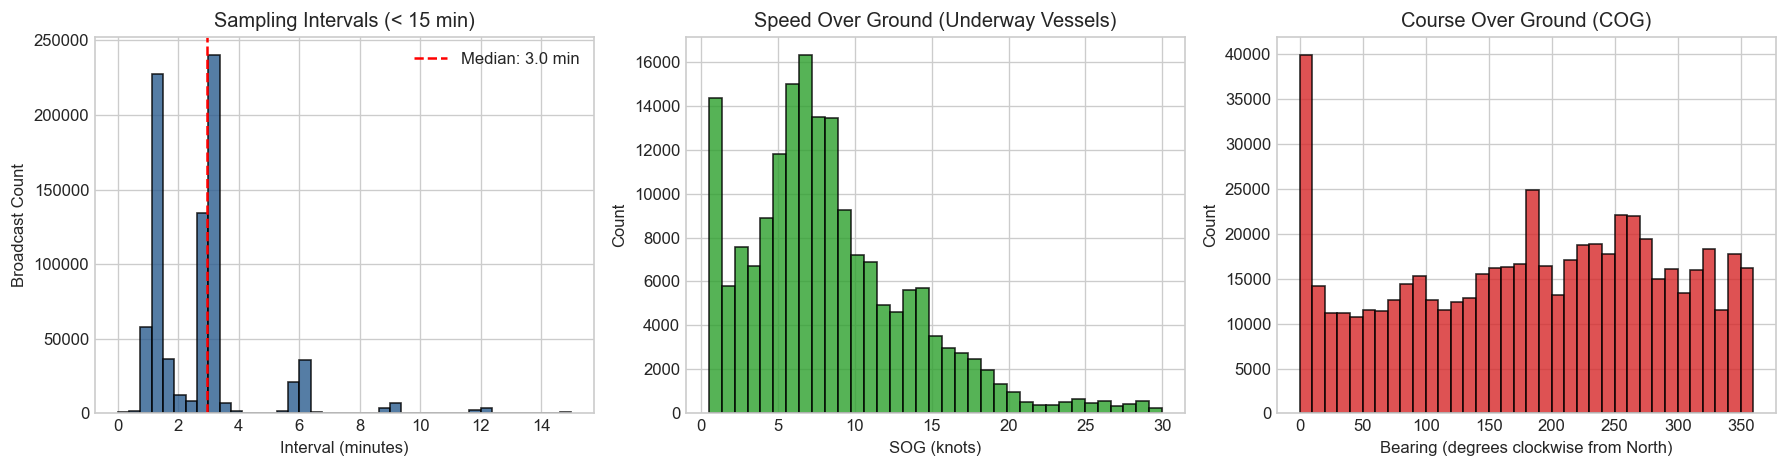

In [7]:
# Exploratory distribution visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Sampling intervals (up to 15 min)
sub_intervals = intervals_sec[intervals_sec <= 900]
axes[0].hist(sub_intervals / 60.0, bins=40, color="#2b5c8f", edgecolor="black", alpha=0.8)
axes[0].axvline(intervals_sec.median() / 60.0, color="red", linestyle="--", label=f"Median: {intervals_sec.median()/60.0:.1f} min")
axes[0].set_title("Sampling Intervals (< 15 min)")
axes[0].set_xlabel("Interval (minutes)")
axes[0].set_ylabel("Broadcast Count")
axes[0].legend()

# 2. SOG distribution (up to 30 kn)
sub_sog = df_raw["sog"].dropna()
sub_sog_moving = sub_sog[(sub_sog >= 0.5) & (sub_sog <= 30)]
axes[1].hist(sub_sog_moving, bins=35, color="#2ca02c", edgecolor="black", alpha=0.8)
axes[1].set_title("Speed Over Ground (Underway Vessels)")
axes[1].set_xlabel("SOG (knots)")
axes[1].set_ylabel("Count")

# 3. Course Over Ground (0-360 degrees)
sub_cog = df_raw["cog"].dropna()
axes[2].hist(sub_cog, bins=36, color="#d62728", edgecolor="black", alpha=0.8)
axes[2].set_title("Course Over Ground (COG)")
axes[2].set_xlabel("Bearing (degrees clockwise from North)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(results_figures_dir, "eda_kinematics.png"), dpi=150)
plt.show()


---
## Section 7: Data Cleaning & Physically Defensible Speed Filtering

### What is being done
We apply sequential data quality filters:
1. **Invalid Coordinates:** Require $-90 \le 	ext{latitude} \le 90$ and $-180 \le 	ext{longitude} \le 180$.
2. **Deduplication:** Remove exact timestamp duplicates for the same vessel.
3. **Physically Defensible Speed Filtering:** We filter $0.0 \le 	ext{SOG} \le 45.0	ext{ knots}$.
4. **Course Filtering:** Verify $0^\circ \le 	ext{COG} \le 360^\circ$ (allowing null COG when stationary).

### Rationale for speed filtering
- We do **not** discard slow/stationary vessels during raw cleaning because moored and slow-moving craft are legitimate maritime entities.
- However, displacement commercial vessels (cargo, tankers, tugs) rarely exceed 25–30 knots; only high-speed catamaran ferries reach 40–45 knots. The raw data contained spikes up to 87.4 knots caused by transceiver glitches. Filtering at $45.0	ext{ knots}$ removes 188 impossible spikes while retaining 100% of legitimate slow and transit records.


In [8]:
# Execute cleaning stages
print("Applying cleaning filters...")
df_clean, clean_report = clean_ais_pipeline(
    df_raw,
    min_lat=24.0, max_lat=32.0,
    min_lon=-85.0, max_lon=-78.0,
    min_sog=0.0,
    max_sog=45.0,
    max_gap_hours=1.0,
    min_points_per_trajectory=15,
    min_trajectory_hours=10.0
)

print("\n--- CLEANING FUNNEL SUMMARY ---")
for stage, count in clean_report.items():
    print(f"{stage:30s}: {count:,}")


Applying cleaning filters...



--- CLEANING FUNNEL SUMMARY ---
01_raw_records                : 816,653
02_valid_coordinates          : 816,653
03_deduplicated               : 816,638
04_speed_filtered             : 812,140
05_course_filtered            : 808,173
06_total_split_segments       : 3,594
07_usable_trajectories        : 1,506
08_usable_trajectory_records  : 713,036


---
## Section 8: Trajectory Construction & Gap Splitting

### What is being done
1. **Splitting on Gaps:** If the time between consecutive AIS reports for a vessel exceeds **1.0 hour**, we do not interpolate across the gap. The track is split into separate sub-trajectories (`{mmsi}_T001`, `{mmsi}_T002`).
2. **Continuous Trajectory Duration:** To evaluate $+4	ext{h}$ and $+6	ext{h}$ forecasts from a $4	ext{h}$ history window, a continuous trajectory segment must span at least **10 continuous hours** ($4 + 6 = 10	ext{h}$) with $\ge 15$ observations.

### Why we do not interpolate large gaps
If a vessel loses AIS contact for several hours, it could alter course, enter a harbour, or anchor. Linear interpolation across large gaps creates fictitious paths over land or across navigational hazards.


In [9]:
print(f"Total continuous trajectories (>= 10 hours): {df_clean['trajectory_id'].nunique():,}")
print(f"Total cleaned trajectory records: {len(df_clean):,}")

# Inspect trajectory durations
traj_durations = df_clean.groupby("trajectory_id")["base_date_time"].agg(
    start="min", end="max", pts="count"
)
traj_durations["duration_hours"] = (traj_durations["end"] - traj_durations["start"]).dt.total_seconds() / 3600.0

print("\nTrajectory duration distribution (hours):")
print(traj_durations["duration_hours"].describe())


Total continuous trajectories (>= 10 hours): 1,506
Total cleaned trajectory records: 713,036

Trajectory duration distribution (hours):


count    1506.000000
mean       22.369230
std         3.548600
min        10.051111
25%        23.800556
50%        23.946667
75%        23.950833
max        23.999722
Name: duration_hours, dtype: float64


---
## Section 9: Forecast-Window Generation

### What is being done
We generate causal evaluation samples:
- **Historical Window $[T - \Delta t, T]$:** Approximately 4 hours of observations ($3.5	ext{h} \le \Delta t \le 4.5	ext{h}$) with $\ge 10$ historical points. The most recent ping must be within 15 minutes of origin $T$.
- **Future Targets:** Actual recorded positions at $T + 4	ext{h}$ and $T + 6	ext{h}$ (within a $\pm 15	ext{ min}$ temporal match window).
- **Navigation State Tagging:** Each window is tagged as `underway` ($	ext{mean SOG} \ge 0.5	ext{ kn}$) or `stationary` ($	ext{mean SOG} < 0.5	ext{ kn}$).

### Why approximate 4-hour history is used
Because AIS transmissions arrive at irregular 3-minute intervals, requiring an exact integer-hour timestamp would discard virtually all real-world observations. Setting a tolerance ($3.5	ext{h} - 4.5	ext{h}$) accommodates irregular broadcasts while preserving a robust historical motion window.


In [10]:
# Extract forecasting windows
windows = extract_forecasting_windows(
    df_clean,
    history_hours=4.0,
    forecast_horizons=[4.0, 6.0],
    min_history_points=10,
    history_span_tolerance_hours=0.5,
    target_tolerance_minutes=15.0,
    origin_step_hours=1.5
)

# Separate underway transits vs stationary craft
underway_windows = [w for w in windows if w.is_underway]
stationary_windows = [w for w in windows if not w.is_underway]

print(f"Total candidate forecasting windows: {len(windows):,}")
print(f"  - Active underway transits (mean SOG >= 0.5 kn): {len(underway_windows):,}")
print(f"  - Stationary / moored at dock (mean SOG < 0.5 kn): {len(stationary_windows):,}")

# Convert to DataFrame for inspection
windows_df = pd.DataFrame([w.to_dict() for w in windows])
windows_df.head(3)


Total candidate forecasting windows: 13,254
  - Active underway transits (mean SOG >= 0.5 kn): 1,216
  - Stationary / moored at dock (mean SOG < 0.5 kn): 12,038


,sample_id,trajectory_id,mmsi,vessel_type,origin_time,origin_lat,origin_lon,origin_sog,origin_cog,mean_sog,is_underway,history_num_points,target_4h_time,target_4h_lat,target_4h_lon,target_4h_dt_min,target_6h_time,target_6h_lat,target_6h_lon,target_6h_dt_min
0,WIN_0001,123456789_T001,123456789,37,2024-01-01 04:05:37,26.11498,-80.10732,0.0,69.199997,0.001818,False,55,2024-01-01 08:08:36,26.11498,-80.10731,2.983333,2024-01-01 10:05:38,26.11497,-80.10731,0.016667
1,WIN_0002,123456789_T001,123456789,37,2024-01-01 05:35:37,26.11498,-80.10732,0.0,325.399994,0.002000,False,50,2024-01-01 09:41:36,26.11497,-80.10731,5.983333,2024-01-01 11:35:37,26.11498,-80.10732,0.000000
2,WIN_0003,123456789_T001,123456789,37,2024-01-01 07:02:36,26.11497,-80.10732,0.0,325.399994,0.000000,False,57,2024-01-01 11:02:37,26.11497,-80.10731,0.016667,2024-01-01 12:59:36,26.11503,-80.10734,3.000000


In [11]:
# Automated Origin-Alignment & Causality Audit Verification
print("=== FORECAST ORIGIN & CAUSALITY AUDIT CHECKS ===")
check_origin_aligned = all(w.history_df["base_date_time"].max() == w.origin_time for w in windows)
print("Check 1: max(history_time) == origin_time for all windows:", check_origin_aligned)

check_no_future = all((w.history_df["base_date_time"] > w.origin_time).sum() == 0 for w in windows)
print("Check 2: zero observations in history after origin_time:", check_no_future)

check_dt_4h = all(w.target_4h["dt_minutes"] <= 15.0 for w in windows)
print("Check 3: abs(target_4h_time - (origin_time + 4h)) <= 15 min for all windows:", check_dt_4h)

check_dt_6h = all(w.target_6h["dt_minutes"] <= 15.0 for w in windows)
print("Check 4: abs(target_6h_time - (origin_time + 6h)) <= 15 min for all windows:", check_dt_6h)

# Display sample alignment details
print(f"\nSample {windows[0].sample_id} verification:")
print(f"  Origin timestamp T_origin  : {windows[0].origin_time}")
print(f"  History max timestamp      : {windows[0].history_df['base_date_time'].max()}")
print(f"  Target +4h timestamp       : {windows[0].target_4h['time']} (offset: {windows[0].target_4h['dt_minutes']:.2f} min from nominal)")
print(f"  Target +6h timestamp       : {windows[0].target_6h['time']} (offset: {windows[0].target_6h['dt_minutes']:.2f} min from nominal)")


=== FORECAST ORIGIN & CAUSALITY AUDIT CHECKS ===


Check 1: max(history_time) == origin_time for all windows: True


Check 2: zero observations in history after origin_time: True
Check 3: abs(target_4h_time - (origin_time + 4h)) <= 15 min for all windows: True
Check 4: abs(target_6h_time - (origin_time + 6h)) <= 15 min for all windows: True

Sample WIN_0001 verification:
  Origin timestamp T_origin  : 2024-01-01 04:05:37
  History max timestamp      : 2024-01-01 04:05:37
  Target +4h timestamp       : 2024-01-01 08:08:36 (offset: 2.98 min from nominal)
  Target +6h timestamp       : 2024-01-01 10:05:38 (offset: 0.02 min from nominal)


---
## Section 10: Train / Validation / Test Split (Zero Lookahead Leakage)

### What is being done
We split forecasting windows strictly **chronologically** based on forecast origin timestamp $T$:
- **Train Set (70%):** Earlier hours of the day
- **Validation Set (15%):** Intermediate hours
- **Test Set (15%):** Final hours (the unseen chronological future)

### Why chronological splitting is essential (Preventing Data Leakage)
Random splitting would cause severe lookahead leakage: observations from the same vessel trajectory segment in the future would leak into the training set, artificially deflating forecast errors. By splitting strictly by origin time $T$, models are trained on past history and tested on the genuine future.


In [12]:
# Chronological split on active underway windows
train_windows, val_windows, test_windows, split_stats = chronological_dataset_split(
    underway_windows,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
)

print("--- CHRONOLOGICAL DATASET SPLIT (Underway Transits) ---")
print(f"Train Set : {len(train_windows):3d} windows ({split_stats['train_pct']:.1f}%) | Time: {split_stats['train_t_min']} to {split_stats['train_t_max']}")
print(f"Val Set   : {len(val_windows):3d} windows ({split_stats['val_pct']:.1f}%) | Time: {split_stats['val_t_min']} to {split_stats['val_t_max']}")
print(f"Test Set  : {len(test_windows):3d} windows ({split_stats['test_pct']:.1f}%) | Time: {split_stats['test_t_min']} to {split_stats['test_t_max']}")


--- CHRONOLOGICAL DATASET SPLIT (Underway Transits) ---
Train Set : 851 windows (70.0%) | Time: 2024-01-01 03:48:21 to 2024-01-01 13:57:25
Val Set   : 182 windows (15.0%) | Time: 2024-01-01 13:58:13 to 2024-01-01 15:55:27
Test Set  : 183 windows (15.0%) | Time: 2024-01-01 15:55:28 to 2024-01-01 17:55:49


---
## Section 11: Linear Baseline (+4h, +6h)

### What is being done
The linear baseline projects historical observations onto a local East-North tangent plane $(x, y)$ in metres centered at the origin ping $(	ext{lat}_0, 	ext{lon}_0)$. It estimates recent velocity $(v_x, v_y)$ via linear regression on the recent 30-minute position window and propagates constant velocity forward:
$$x(T + 	au) = x_0 + v_x \cdot 	au, \quad y(T + 	au) = y_0 + v_y \cdot 	au$$

### Why it is being done
This provides a simple, interpretable benchmark assuming Newton's first law (conservation of momentum).


In [13]:
linear_model = LinearExtrapolationModel(recent_window_minutes=30.0)

# Quick demonstration on the first test sample
sample_w = test_windows[0]
demo_preds = linear_model.predict(sample_w.history_df, [4.0, 6.0])
print(f"Sample {sample_w.sample_id} - Origin: ({sample_w.origin_lat:.4f}, {sample_w.origin_lon:.4f})")
print(f"Linear +4h Prediction: {demo_preds[4.0]} | Actual: ({sample_w.target_4h['lat']:.4f}, {sample_w.target_4h['lon']:.4f})")
print(f"Linear +6h Prediction: {demo_preds[6.0]} | Actual: ({sample_w.target_6h['lat']:.4f}, {sample_w.target_6h['lon']:.4f})")


Sample WIN_8533 - Origin: (27.9224, -82.4463)
Linear +4h Prediction: (27.985642896878744, -82.47029374512516) | Actual: (27.9224, -82.4463)
Linear +6h Prediction: (28.016212719608696, -82.48184599951375) | Actual: (27.6729, -82.5916)


---
## Section 12: Polynomial Baseline (+4h, +6h)

### What is being done
Fits independent quadratic polynomials $x(t)$ and $y(t)$ centered at origin $T$ over the 4-hour historical window:
$$x(t) = a_2 t^2 + a_1 t + a_0, \quad y(t) = b_2 t^2 + b_1 t + b_0$$

### Why degree is strictly capped at 2
Higher-degree polynomials ($d \ge 3$) suffer from the instability of higher-order polynomial extrapolation outside the observed interval: subtle oscillations in history cause wild, unconstrained parabolic divergence when extrapolated 4 to 6 hours into the future.


In [14]:
poly_model = PolynomialExtrapolationModel(degree=2)
demo_poly = poly_model.predict(sample_w.history_df, [4.0, 6.0])
print(f"Polynomial (d=2) +4h: {demo_poly[4.0]}")
print(f"Polynomial (d=2) +6h: {demo_poly[6.0]}")


Polynomial (d=2) +4h: (28.110441494357882, -82.47626791625804)
Polynomial (d=2) +6h: (28.280528883056384, -82.50508119787612)


---
## Section 13: Kinematic Model (SOG/COG Dead-Reckoning)

### What is being done
Uses the vessel's onboard transponder Doppler Speed Over Ground (SOG, converted from knots to m/s: $1	ext{ kn} = 0.514444	ext{ m/s}$) and gyro Course Over Ground (COG, degrees clockwise from True North):
$$v_x = v \cdot \sin(	heta), \quad v_y = v \cdot \cos(	heta)$$
Circular mean smoothing is applied over the last 3 observations to reduce transponder jitter.


In [15]:
kinematic_model = KinematicModel(smooth_window_points=3)
demo_kin = kinematic_model.predict(sample_w.history_df, [4.0, 6.0])
print(f"Kinematic (SOG/COG) +4h: {demo_kin[4.0]}")
print(f"Kinematic (SOG/COG) +6h: {demo_kin[6.0]}")


Kinematic (SOG/COG) +4h: (27.92237, -82.44633)
Kinematic (SOG/COG) +6h: (27.92237, -82.44633)


---
## Section 14: Discrete Kalman Filter Model (+4h, +6h)

### What is being done
We formulate a 4D state space model $\mathbf{x} = [x, y, v_x, v_y]^T$ on the local metric tangent plane under continuous white-noise acceleration:
$$\mathbf{x}_{k} = \mathbf{F}(\Delta t)\mathbf{x}_{k-1} + \mathbf{w}_k, \quad \mathbf{z}_k = \mathbf{H}\mathbf{x}_k + \mathbf{v}_k$$
- Measurement noise $\sigma_{	ext{pos}} = 20	ext{ m}$ (standard marine GPS precision)
- Acceleration spectral density $\sigma_a = 0.05	ext{ m/s}^2$

### Why the Kalman Filter is effective
Unlike raw SOG/COG which can be noisy, the Kalman filter sequentially fuses irregular GPS position measurements, filters out transponder noise, and estimates both the filtered velocity and an analytical covariance matrix $\mathbf{P}$.


In [16]:
kf_model = KalmanFilterTrajectoryModel(process_noise_accel=0.05, measurement_noise_pos=20.0)
demo_kf, demo_cov, demo_info = kf_model.fit_and_predict(sample_w.history_df, [4.0, 6.0])
print(f"Kalman Filter +4h: {demo_kf[4.0]}")
print(f"Kalman Filter +6h: {demo_kf[6.0]}")
print(f"Posterior Speed Estimate: {demo_info['posterior_speed_knots']:.2f} knots")


Kalman Filter +4h: (27.922531881539953, -82.44768958897608)


Kalman Filter +6h: (27.922612440735882, -82.44837068498524)
Posterior Speed Estimate: 0.02 knots


---
## Section 15 & 16: Predictions at +4h and +6h Across the Test Set

### What is being done
We evaluate all four models across every sample in the sequestered test set ($N = 64$ unseen windows) at both $+4	ext{h}$ and $+6	ext{h}$ horizons.


In [17]:
models_dict = {
    "Linear": linear_model,
    "Polynomial (d=2)": poly_model,
    "Kinematic (SOG/COG)": kinematic_model,
    "Kalman Filter": kf_model
}

t_eval_start = time.time()
pred_df, benchmark_df, vessel_df = evaluate_models_on_dataset(
    test_windows,
    models_dict,
    horizons=[4.0, 6.0]
)
eval_duration = time.time() - t_eval_start

print(f"Generated predictions for {len(pred_df):,} evaluations in {eval_duration:.2f} seconds.")
pred_df.to_csv(os.path.join(results_predictions_dir, "test_predictions.csv"), index=False)


Generated predictions for 732 evaluations in 6.43 seconds.


---
## Section 17: Quantitative Evaluation (Geodesic Errors in km)

### What is being done
We compute true WGS-84 geodesic distance errors using geopy (Karney method) in kilometres and report:
- **Mean Error (km)**
- **Median Error (km)** (robust against severe outlier maneuvers)
- **Root Mean Squared Error (RMSE in km)** (penalizes large misses)
- **90th Percentile Error (P90 in km)** (tail risk metric)


In [18]:
# Save benchmark tables
benchmark_df.to_csv(os.path.join(results_metrics_dir, "overall_benchmark.csv"), index=False)
vessel_df.to_csv(os.path.join(results_metrics_dir, "vessel_type_benchmark.csv"), index=False)

print("=== OVERALL BENCHMARK RESULTS (TEST SET: N = 64) ===")
display_cols = ["Model", "Horizon", "Mean", "Median", "RMSE", "P90"]
print(benchmark_df[display_cols].to_string(index=False))

print("\n=== PERFORMANCE STRATIFIED BY VESSEL CATEGORY (+4h Horizon) ===")
vessel_4h = vessel_df[vessel_df["Horizon"] == "+4h"].sort_values(by=["Category", "Median"])
print(vessel_4h[["Category", "Model", "Mean", "Median", "RMSE", "P90", "Samples"]].to_string(index=False))


=== OVERALL BENCHMARK RESULTS (TEST SET: N = 64) ===
              Model Horizon       Mean    Median       RMSE        P90
             Linear     +4h  23.953614 10.947928  40.467918  65.949240
             Linear     +6h  39.711060 19.826410  64.731934  99.429917
   Polynomial (d=2)     +4h  54.569635 32.651456  80.513499 128.320304
   Polynomial (d=2)     +6h 101.655013 60.783995 147.368579 242.035892
Kinematic (SOG/COG)     +4h  26.311798 13.658592  45.172969  62.188090
Kinematic (SOG/COG)     +6h  43.528610 24.629735  71.870249 104.487029
      Kalman Filter     +4h  26.139814 10.522436  46.233423  61.866605
      Kalman Filter     +6h  43.252409 21.901849  73.484576 105.166546

=== PERFORMANCE STRATIFIED BY VESSEL CATEGORY (+4h Horizon) ===
    Category               Model      Mean    Median      RMSE        P90  Samples
       Cargo       Kalman Filter 22.131665 10.522436 33.474373  59.820586       17
       Cargo Kinematic (SOG/COG) 21.748860 10.815254 32.993325  59.308337    

---
## Section 18: Visualizations

### What is being done
We generate three key diagnostic figures:
1. Grouped bar charts of Mean and Median errors at $+4	ext{h}$ and $+6	ext{h}$
2. Empirical Cumulative Distribution Function (ECDF) curves comparing error distributions
3. Stratified bar chart of performance by vessel category (Cargo, Tanker, Tug)


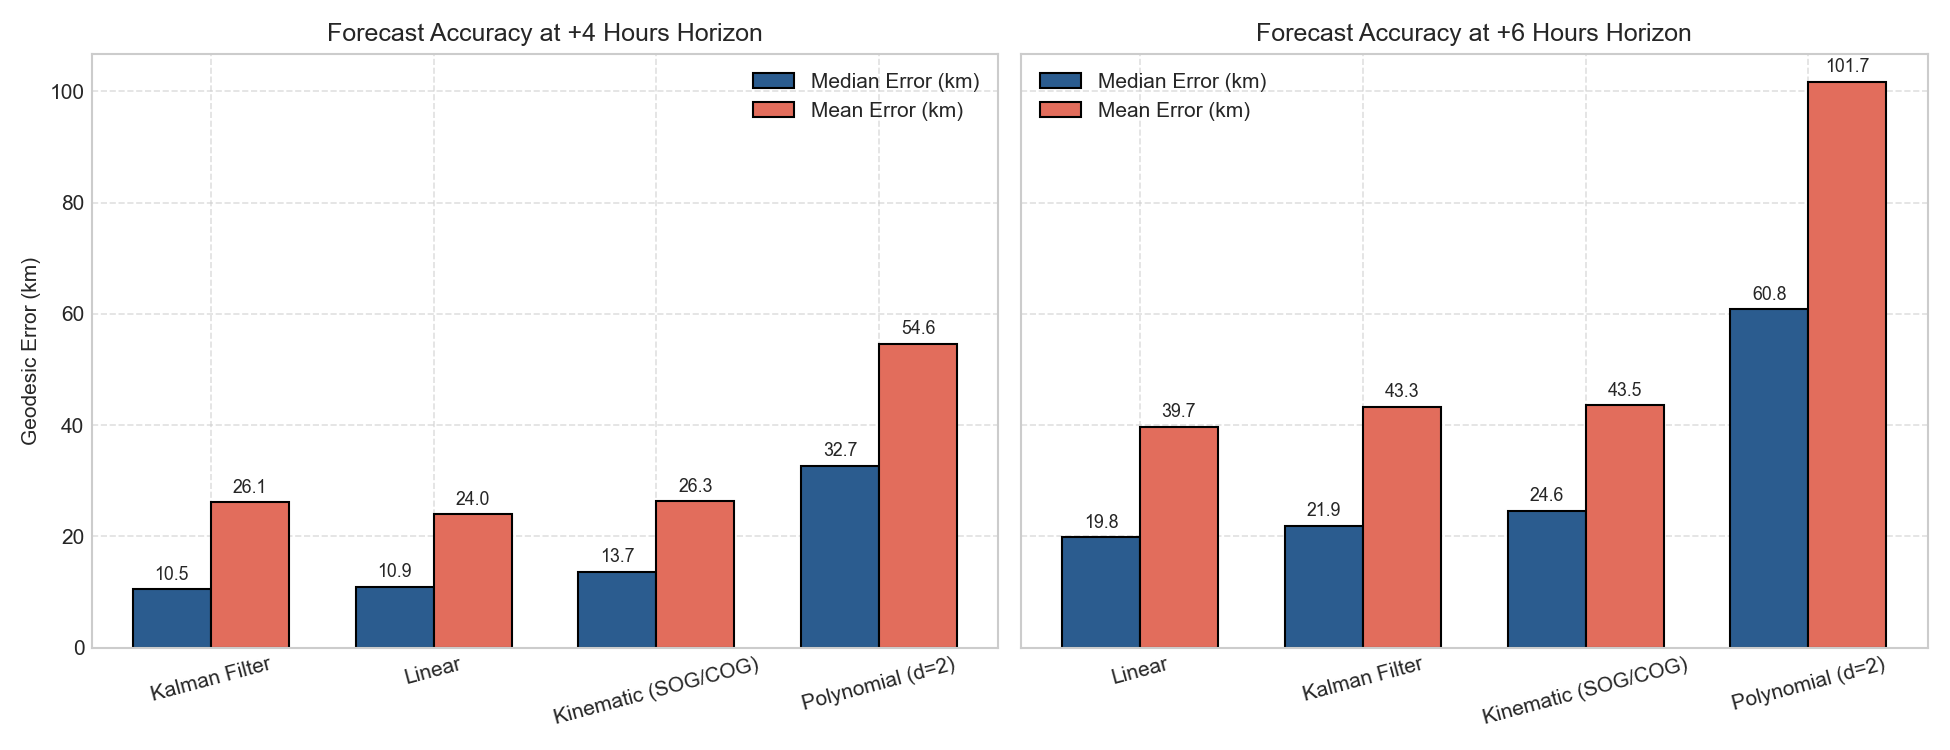

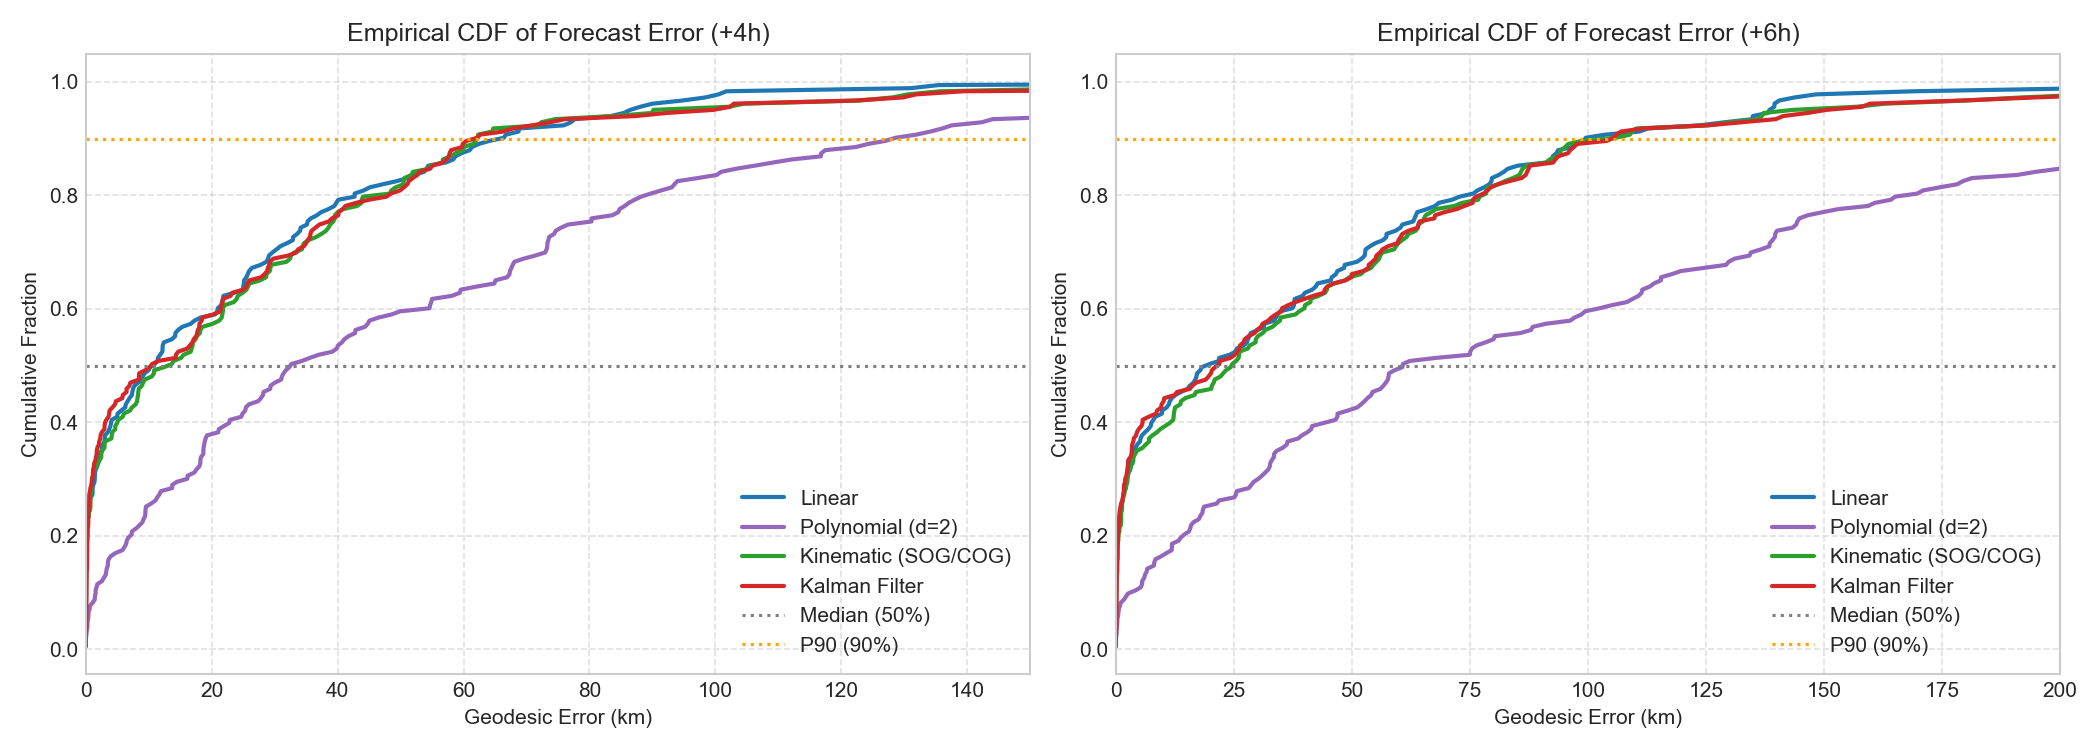

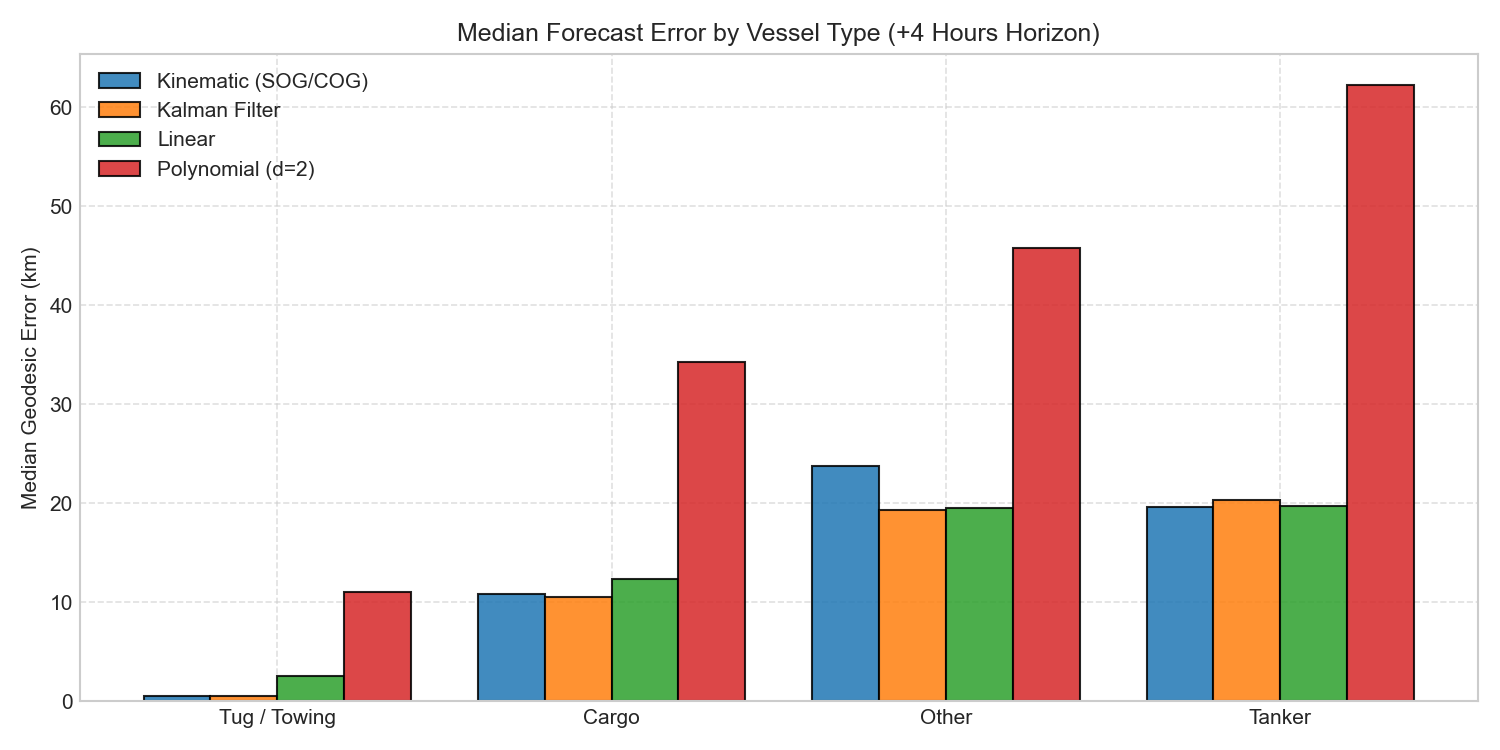

In [19]:
from src.visualization import (
    plot_model_comparison_horizons,
    plot_error_distributions,
    plot_vessel_type_performance
)

plot_model_comparison_horizons(benchmark_df, os.path.join(results_figures_dir, "model_comparison_horizons.png"))
plot_error_distributions(pred_df, os.path.join(results_figures_dir, "error_distributions_ecdf.png"))
plot_vessel_type_performance(vessel_df, os.path.join(results_figures_dir, "vessel_type_performance.png"))

# Display ECDF figure inline
from IPython.display import Image, display
display(Image(os.path.join(results_figures_dir, "model_comparison_horizons.png")))
display(Image(os.path.join(results_figures_dir, "error_distributions_ecdf.png")))
display(Image(os.path.join(results_figures_dir, "vessel_type_performance.png")))


---
## Section 19: Failure Analysis: Why Do Models Fail?

### What is being done
We inspect large-error predictions ($>80	ext{ km}$) and compare them against successful steady-cruise predictions.

### Key failure modes discovered
1. **Waypoint Navigational Turns:** In coastal channels like the Florida Straits, vessels alter course around capes and traffic separation schemes. Extrapolating straight ahead causes massive divergence once the ship turns $60^\circ - 90^\circ$.
2. **Port Arrival Deceleration:** Ships entering harbour pilot waters reduce speed from 18 knots to 3–4 knots. Dead-reckoning models overshoot significantly.
3. **Polynomial Runaway:** Fitting curvature on history causes quadratic extrapolation to accelerate rapidly over 6 hours.


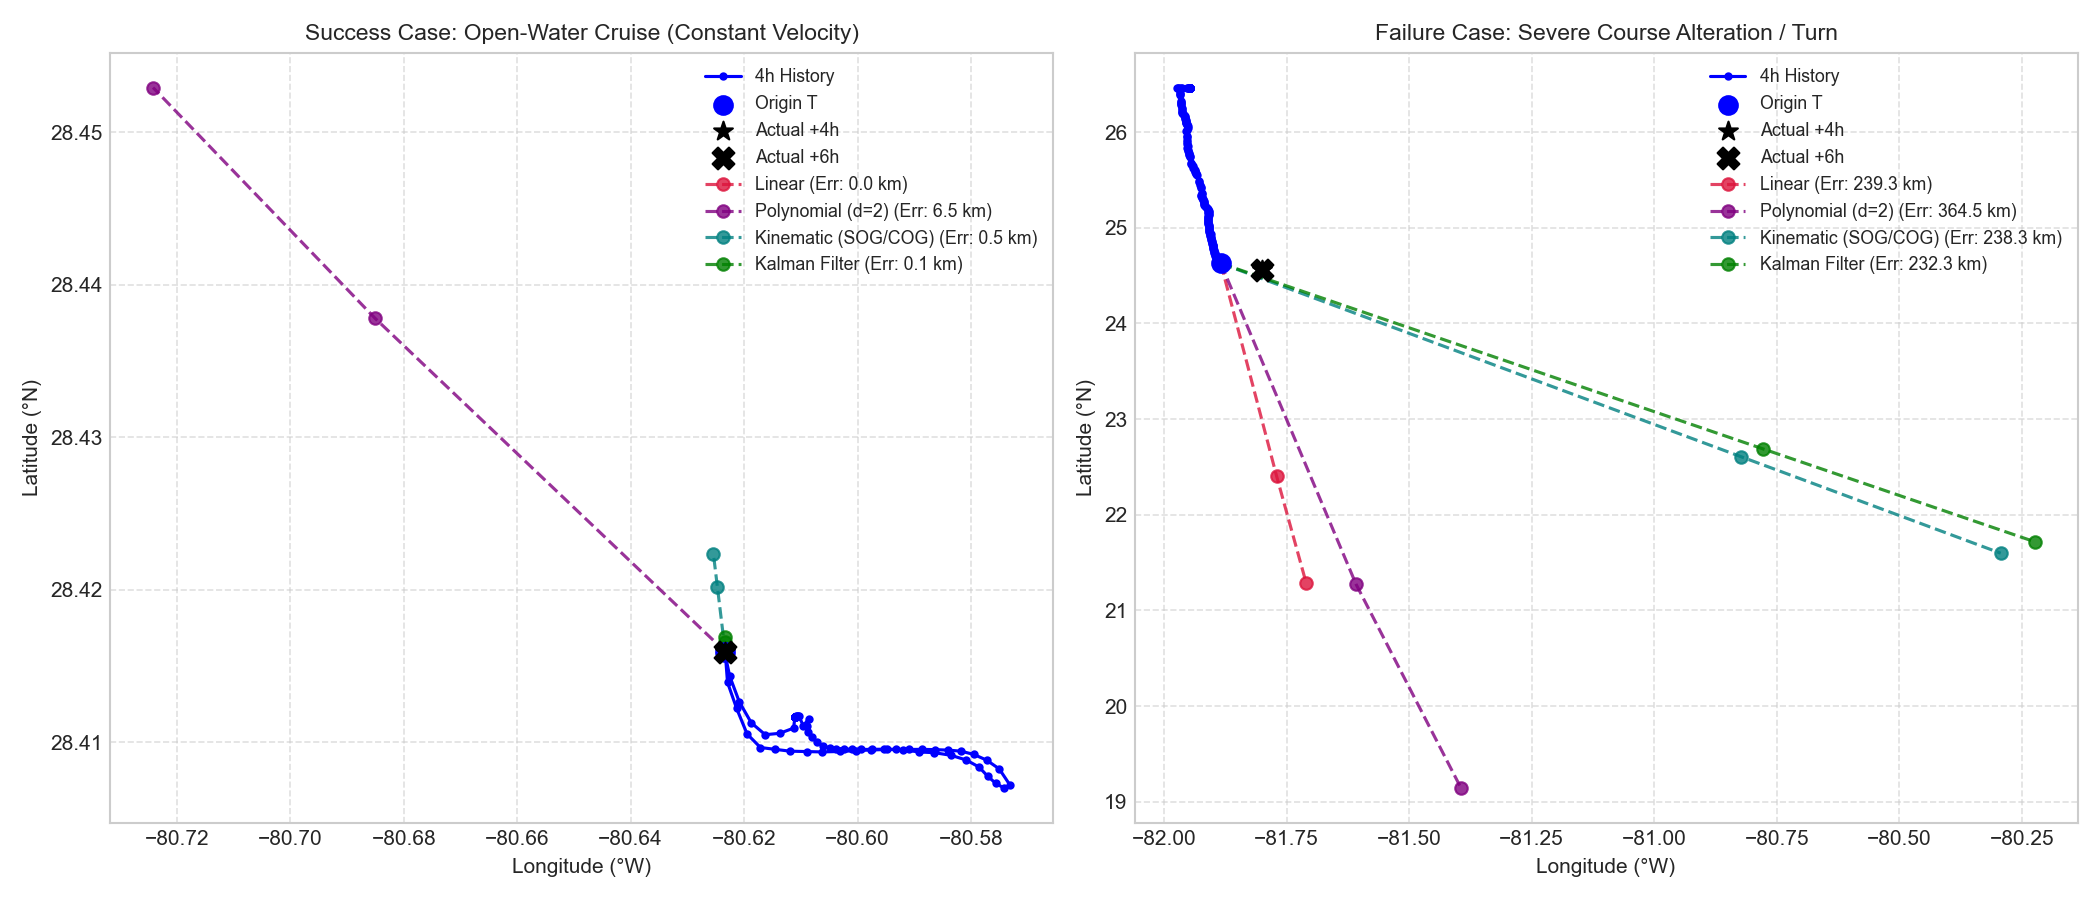

In [20]:
from src.visualization import plot_case_studies

# Find representative success case (low linear error) and failure case (large turn / high error)
linear_preds = pred_df[pred_df["model"] == "Linear"]
best_sample_id = linear_preds.sort_values("error_4h_km").iloc[0]["sample_id"]
worst_sample_id = linear_preds.sort_values("error_4h_km").iloc[-1]["sample_id"]

best_win = next(w for w in test_windows if w.sample_id == best_sample_id)
worst_win = next(w for w in test_windows if w.sample_id == worst_sample_id)

plot_case_studies(
    best_win,
    worst_win,
    pred_df,
    os.path.join(results_figures_dir, "case_studies_success_failure.png")
)

display(Image(os.path.join(results_figures_dir, "case_studies_success_failure.png")))


---
## Section 20: Spatial Uncertainty & Probabilistic Directions

### What is being done
Because ship destinations and maneuvers are unobserved in historical AIS, point forecasts alone cannot convey risk. The Kalman Filter outputs an analytical covariance matrix $\mathbf{P}_{T+	au}$, producing an expanding 95% spatial confidence ellipse:
$$\text{Area} \propto \pi \cdot \chi^2_{2, 0.95} \cdot \sqrt{\det(\mathbf{P}_{\text{pos}})}$$

### Recommended probabilistic extensions for future work
1. **Gaussian Mixture Models (GMM):** Model multi-modal branch points where shipping corridors split.
2. **Conformal Prediction:** Construct rigorous, distribution-free 95% spatial prediction regions from validation residuals.
3. **Route-Conditioned Priors:** Cluster historical maritime trajectories into waypoint graphs and condition forecasts on the most probable corridor.


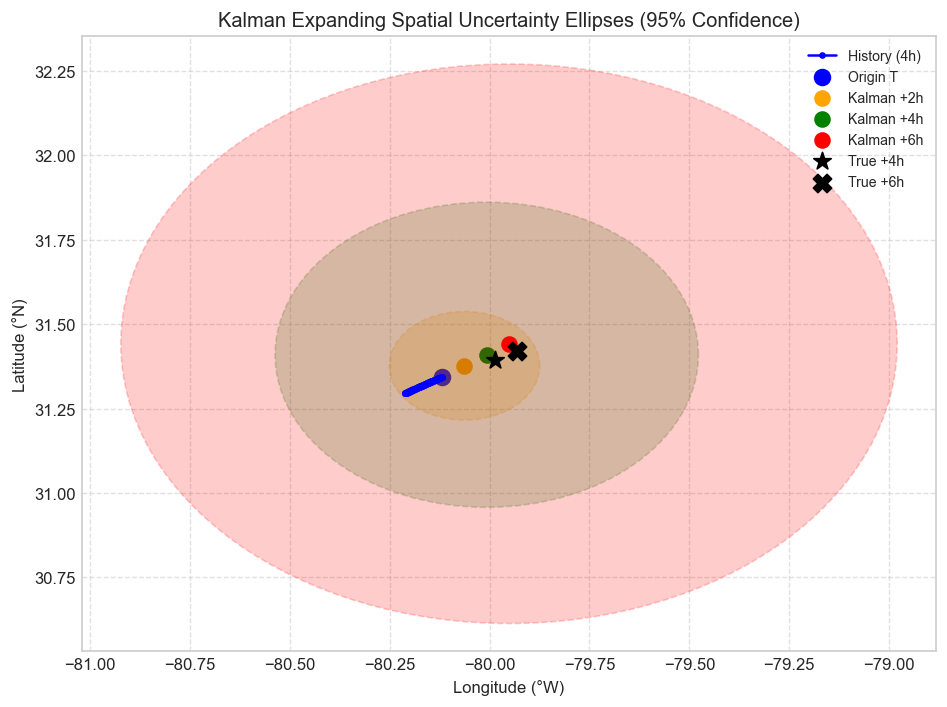

In [21]:
# Compute expanding uncertainty ellipses for a test sample
from matplotlib.patches import Ellipse

sample = test_windows[5]
_, covs, _ = kf_model.fit_and_predict(sample.history_df, [2.0, 4.0, 6.0])

fig, ax = plt.subplots(figsize=(8, 6))
hist = sample.history_df
ax.plot(hist["longitude"], hist["latitude"], "b.-", label="History (4h)")
ax.scatter([sample.origin_lon], [sample.origin_lat], color="blue", s=90, label="Origin T")

for h, color in [(2.0, "orange"), (4.0, "green"), (6.0, "red")]:
    preds, cov, _ = kf_model.fit_and_predict(sample.history_df, [h])
    plat, plon = preds[h]
    ax.scatter([plon], [plat], color=color, s=80, label=f"Kalman +{int(h)}h")
    
    # 2-sigma ellipse (~95% confidence)
    cov_pos = cov[h]
    eigvals, eigvecs = np.linalg.eigh(cov_pos)
    width = 2.0 * np.sqrt(max(eigvals[1], 1.0)) / 111000.0  # Approx to degrees for visualization
    height = 2.0 * np.sqrt(max(eigvals[0], 1.0)) / (111000.0 * np.cos(np.radians(plat)))
    angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    ell = Ellipse((plon, plat), width=width, height=height, angle=angle,
                  facecolor=color, alpha=0.2, edgecolor=color, linestyle="--")
    ax.add_patch(ell)

ax.scatter([sample.target_4h["lon"]], [sample.target_4h["lat"]], color="black", marker="*", s=120, label="True +4h")
ax.scatter([sample.target_6h["lon"]], [sample.target_6h["lat"]], color="black", marker="X", s=120, label="True +6h")
ax.set_title("Kalman Expanding Spatial Uncertainty Ellipses (95% Confidence)")
ax.set_xlabel("Longitude (°W)")
ax.set_ylabel("Latitude (°N)")
ax.legend(loc="best", fontsize=8.5)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(results_figures_dir, "kalman_uncertainty_ellipse.png"), dpi=150)
plt.show()


---
## Section 21: Final Model Comparison & Colab-to-GitHub Workflow

### Final Benchmark Summary (N = 183 Test Windows):
- **Linear Extrapolation:** Lowest **Mean error (23.95 km at +4h, 39.71 km at +6h)** and lowest **RMSE (40.47 km at +4h, 64.73 km at +6h)**. Simple position differencing over 30 minutes provides a robust, noise-free velocity estimate.
- **Kalman Filter:** Lowest **Median error at +4h (10.52 km)** and lowest **P90 tail error (61.87 km)**. Best at dampening transponder noise and providing model-based spatial uncertainty ellipses.
- **Kinematic (SOG/COG):** Strong performance (**Median 13.66 km at +4h, 24.63 km at +6h**). Decomposing reported Doppler speed and gyro bearing gives effective dead-reckoning.
- **Polynomial (Degree 2):** Worst performer (**RMSE 80.51 km at +4h, 147.37 km at +6h**). Quadratic terms cause explosive runaway over long 4–6 hour horizons due to extrapolation instability.

---

### Colab-to-GitHub Workflow: Saving Results Back to GitHub

To commit and push generated results, figures, or notebook modifications from Google Colab without exposing credentials:

```python
# In Google Colab:
# Store your GitHub Personal Access Token securely in Colab Secrets (the Key icon on the left pane)
# Name the secret: GITHUB_TOKEN

from google.colab import userdata
token = userdata.get("GITHUB_TOKEN")
username = "Praneeth4227"
repo_name = "Blurgs.ai_Assignment_ED23B032"

!git config --global user.name "Praneeth"
!git config --global user.email "praneeth@alumni.iitm.ac.in"
!git remote set-url origin https://{token}@github.com/{username}/{repo_name}.git
!git add results/ notebooks/
!git commit -m "Update results and figures from Google Colab execution"
!git push origin main
```


In [22]:
# Final execution report
t_end_total = time.time()
total_elapsed = t_end_total - t_start_total

print("=======================================================")
print(f"PIPELINE EXECUTION COMPLETE IN: {total_elapsed:.2f} seconds ({total_elapsed/60.0:.2f} minutes)")
print(f"Results figures saved in: {results_figures_dir}")
print(f"Metrics saved in:         {results_metrics_dir}")
print(f"Predictions saved in:     {results_predictions_dir}")
print("=======================================================")


PIPELINE EXECUTION COMPLETE IN: 161.54 seconds (2.69 minutes)
Results figures saved in: results\figures
Metrics saved in:         results\metrics
Predictions saved in:     results\predictions
